# Tests Complets pour l'Implémentation FCI

Ce notebook contient tous les tests nécessaires pour évaluer l'algorithme FCI selon les critères du projet MADI:
- Tests sur données simulées
- Comparaison avec MIIC (pyAgrum)
- Analyse de structure et complexité computationnelle

## 1. Installation et Imports

In [1]:
!pip install pyagrum numpy pandas graphviz matplotlib

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
import pgmpy
import graphviz
import numpy as np
import matplotlib.pyplot as plt
# from causallearn.search.ConstraintBased.FCI import fci
# from causallearn.utils.cit import fisherz, gsq
# from causallearn.utils.GraphUtils import GraphUtils
# from IPython.display import Image, display

# mr = gum.MeekRules()

In [3]:
%load_ext autoreload
%autoreload 2

from FCI import *
import utils

## 2. Test d'implémentation Réseau Bayésien Simple 

Test 1: Réseau simple (4 variables)
------------------------------------------------------------
Réseau créé: 5 variables, 6 arcs


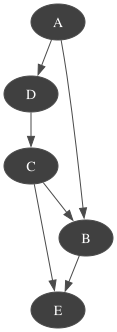

In [4]:
# Création d'un réseau bayésien simple
print("Test 1: Réseau simple (4 variables)")
print("-" * 60)

bn_simple = gum.BayesNet("Simple_Network")

a = bn_simple.add(gum.LabelizedVariable('A', 'Variable A', 2))
b = bn_simple.add(gum.LabelizedVariable('B', 'Variable B', 2))
c = bn_simple.add(gum.LabelizedVariable('C', 'Variable C', 2))
d = bn_simple.add(gum.LabelizedVariable('D', 'Variable D', 2))
e = bn_simple.add(gum.LabelizedVariable('E', 'Variable E', 2))


bn_simple.addArc(a, b)
bn_simple.addArc(a, d)
bn_simple.addArc(b, e)
bn_simple.addArc(c, b)
bn_simple.addArc(c, e)
bn_simple.addArc(d, c)


bn_simple.generateCPTs()

print(f"Réseau créé: {bn_simple.size()} variables, {bn_simple.sizeArcs()} arcs")

# Visualisation
gnb.showBN(bn_simple)

In [5]:
# Génération des données
df_simple,_ = utils.generate_test_data(bn_simple, n_samples=5000)
print(f"Données générées: {len(df_simple)} échantillons")
print(f"\nAperçu des données:")
latent_var = (0,df_simple.columns[0])
df_latente = df_simple.drop(columns=latent_var[1])
print(f"{latent_var=}")
df_simple.head()

Données générées: 5000 échantillons

Aperçu des données:
latent_var=(0, 'A')


,A,B,C,D,E
0,1,0,0,1,0
1,1,0,0,1,1
2,0,0,0,1,0
3,0,1,0,1,0
4,0,0,1,1,1


Exécution de FCI...
FCI terminé en 0.026s

Ensemble séparateur :
{('A', 'E'): {'B'}, ('B', 'D'): {'C'}, ('D', 'E'): {'C'}}

Arêtes du squelette :
{('A', 'B'), ('C', 'E'), ('C', 'D'), ('A', 'D'), ('B', 'C'), ('B', 'E')}

PAG résultant (FCI):


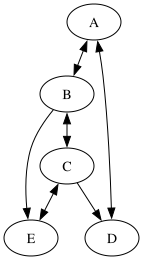

In [6]:
# Test FCI simple
print("Exécution de FCI...")
fci_simple, fci_time_simple = utils.measure_execution_time(run_FCI, df_simple, alpha=0.05, useGum=True)
print(f"FCI terminé en {fci_time_simple:.3f}s")

print("\nEnsemble séparateur :")
set_sep = {}
labels = fci_simple.get_variables()
for key, value in fci_simple.get_separators().items():
    (i,j)= key
    for e in value :
        set_sep[(labels[i],labels[j])] = {labels[e] if e != {} else set()}
print(set_sep)

print('\nArêtes du squelette :')
fci_struct = utils.get_fci_structure(fci_simple)
print(fci_struct['edges'])

# Visualisation du résultat FCI
print("\nPAG résultant (FCI):")
fci_simple.toDot()

Exécution de FCI (Gum=False)...
FCI terminé en 0.204s

PAG résultant (FCI):


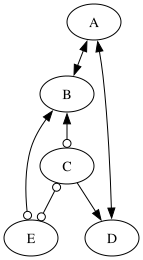

In [7]:
# Test FCI sans Gum
print("Exécution de FCI (Gum=False)...")
fci_simple, fci_time_simple = utils.measure_execution_time(run_FCI, df_simple, alpha=0.05, useGum=False)
print(f"FCI terminé en {fci_time_simple:.3f}s")

# Visualisation du résultat FCI
print("\nPAG résultant (FCI):")
# print(fci_simple.get_variables())
fci_simple.toDot()

## 3. Comparaison avec MIIC

Exécution de MIIC...
MIIC terminé en 0.007s

PDAG résultant (MIIC):


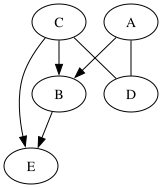

In [8]:
# Test MIIC
print("Exécution de MIIC...")
learner_simple = gum.BNLearner(df_simple)

def run_miic(learner):
    learner.useMIIC()
    return learner.learnPDAG()

miic_simple, miic_time_simple = utils.measure_execution_time(run_miic, learner_simple)
print(f"MIIC terminé en {miic_time_simple:.3f}s")

# Visualisation du résultat MIIC
print("\nPDAG résultant (MIIC):")
# utils.labelize_pdag_nodes(miic_simple, bn_simple, latent_var)
utils.labelize_pdag_nodes(miic_simple, bn_simple)

In [9]:
# comparison = utils.compare_structures(fci_simple, miic_simple, bn_simple, fci_time_simple, miic_time_simple, latent_variable=latent_var)
comparison = utils.compare_structures(fci_simple, miic_simple, bn_simple, fci_time_simple, miic_time_simple)

------------------------------------------------------------
COMPARAISON FCI vs MIIC
------------------------------------------------------------
Structure:
  FCI  - Total arêtes du squelette: 6
       - Orientées: 5
       - Taux de certitude: 33% (4/12)
  MIIC - Total arêtes du squelette : 6
       - Arcs: 4

Similarité:
  Arêtes communes: 6
  Jaccard similarity sur squelette: 1.000

Temps d'exécution:
  FCI:  0.204s
  MIIC: 0.007s
  Ratio (FCI/MIIC): 28.35x


### Test avec variable latente artificielle

Exécution de FCI (avec variable latente)...
FCI terminé en 0.013s

Ensemble séparateur :
{('B', 'D'): {'C'}, ('D', 'E'): {'C'}}

Arêtes du squelette :
{('B', 'C'), ('C', 'E'), ('C', 'D'), ('B', 'E')}

PAG résultant (FCI):


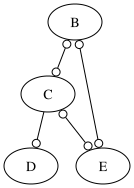

In [10]:
# Test FCI avec variable latente artificielle
print("Exécution de FCI (avec variable latente)...")
fci_latent, fci_time_latent = utils.measure_execution_time(run_FCI, df_latente, alpha=0.05, useGum=True)
print(f"FCI terminé en {fci_time_latent:.3f}s")

print("\nEnsemble séparateur :")
set_sep = {}
labels = fci_latent.get_variables()
for key, value in fci_latent.get_separators().items():
    (i,j)= key
    for e in value :
        set_sep[(labels[i],labels[j])] = {labels[e] if e != {} else set()}
print(set_sep)

print('\nArêtes du squelette :')
fci_struct = utils.get_fci_structure(fci_latent)
print(fci_struct['edges'])

# Visualisation du résultat FCI
print("\nPAG résultant (FCI):")
fci_latent.toDot()

Exécution de MIIC (variable latente)...
MIIC terminé en 0.002s

PDAG résultant (MIIC):


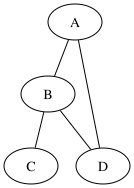

In [11]:
# Test MIIC
print("Exécution de MIIC (variable latente)...")
learner_simple = gum.BNLearner(df_latente)

def run_miic(learner):
    learner.useMIIC()
    return learner.learnPDAG()

miic_latente, miic_time_latente = utils.measure_execution_time(run_miic, learner_simple)
print(f"MIIC terminé en {miic_time_latente:.3f}s")

# Visualisation du résultat MIIC
print("\nPDAG résultant (MIIC):")
# utils.labelize_pdag_nodes(miic_simple, bn_simple, latent_var)
utils.labelize_pdag_nodes(miic_latente, bn_simple)

In [12]:
comparison_latent = utils.compare_structures(fci_latent, miic_latente, bn_simple, fci_time_latent, miic_time_simple, latent_variable=latent_var)

------------------------------------------------------------
COMPARAISON FCI vs MIIC
------------------------------------------------------------
Structure:
  FCI  - Total arêtes du squelette: 4
       - Orientées: 0
       - Taux de certitude: 88% (7/8)
  MIIC - Total arêtes du squelette : 4
       - Arcs: 0

Similarité:
  Arêtes communes: 4
  Jaccard similarity sur squelette: 1.000

Temps d'exécution:
  FCI:  0.013s
  MIIC: 0.007s
  Ratio (FCI/MIIC): 1.74x


### Supplémentaire : transformation du PAG de FCI en PDAG
#### Option 1

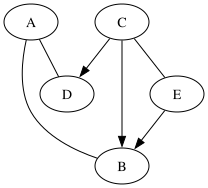

In [13]:
graph = fci_simple.return_PDAG(opt=1)
utils.labelize_pdag_nodes(graph, fci_simple)

#### Option 2

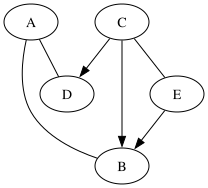

In [14]:
graph = fci_simple.return_PDAG(opt=2)
utils.labelize_pdag_nodes(graph, fci_simple)

#### Option 3

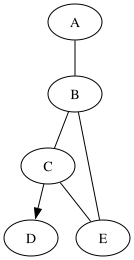

In [15]:
graph = fci_simple.return_PDAG(opt=3)
utils.labelize_pdag_nodes(graph, fci_simple)

## 4. Analyse selon les paramètres
Paramètres analysés :
- taille de l'échantillon 
- taille du réseau bayésien
- paramètre alpha

In [17]:
print("Analyse")
print("-" * 60)

n_vars_list = [4, 6, 8, 10, 12, 14]
n_samples = [100, 1000, 10000]
total_fci_times = {}
total_rfci_times = {}
total_miic_times = {}
total_n_edges_fci = {}
total_n_edges_miic = {}
total_jaccard_similarities = {}
total_uncertainty_score = {}
total_ratios = {}

for s in n_samples:
    print(f"\nTest avec écahntillon de taill {s} ...")
    fci_times = []
    rfci_times = []
    miic_times = []
    n_edges_fci = []
    n_edges_miic = []
    jaccard_similarities = []
    uncertainty_score = []
    ratios = []
    for n in n_vars_list:
        print(f"\nTest avec {n} variables...")
        
        # Création du réseau
        bn_test = gum.randomBN(n=n, names=[f'X{i}' for i in range(n)])
        bn_test.generateCPTs()
        
        # Génération des données
        df_test,_ = utils.generate_test_data(bn_test, n_samples=s)
        # index = np.random.randint(0, len(df_test.columns))
        # latent_var = (index, df_test.columns[index])
        # df_test = df_test.drop(columns=latent_var[1])
        # print(f"{latent_var=}")
        
        # FCI
        fci_result, t_fci = utils.measure_execution_time(run_FCI, df_test, alpha=0.05, useGum=True)
        fci_times.append(t_fci)
        
        # RFCI
        # rfci_result, t_rfci = utils.measure_execution_time(run_RFCI, df_test, alpha=0.05, useGum=True, bayesnet=bn_test)
        # rfci_times.append(t_rfci)
        
        # MIIC
        learner_test = gum.BNLearner(df_test)
        miic_result, t_miic = utils.measure_execution_time(run_miic, learner_test)
        miic_times.append(t_miic)

        comparison = utils.compare_structures(fci_result, miic_result, bn_test, t_fci, t_miic, verbose=False)
        n_edges_fci.append(comparison['fci_total'])
        n_edges_miic.append(comparison['miic_total'])
        jaccard_similarities.append(comparison['jaccard_similarity'])
        uncertainty_score.append(comparison['fci_uncertainty_score'])
        ratios.append(comparison['t_ratio'])

    total_fci_times[s] = fci_times
    total_miic_times[s] = miic_times
    total_n_edges_fci[s] = n_edges_fci
    total_n_edges_miic[s] = n_edges_miic
    total_jaccard_similarities[s] = jaccard_similarities
    total_uncertainty_score[s] = uncertainty_score
    total_ratios[s] = ratios

Analyse
------------------------------------------------------------

Test avec écahntillon de taill 100 ...

Test avec 4 variables...

Test avec 6 variables...

Test avec 8 variables...

Test avec 10 variables...

Test avec 12 variables...

Test avec 14 variables...

Test avec écahntillon de taill 1000 ...

Test avec 4 variables...

Test avec 6 variables...

Test avec 8 variables...

Test avec 10 variables...

Test avec 12 variables...

Test avec 14 variables...

Test avec écahntillon de taill 10000 ...

Test avec 4 variables...

Test avec 6 variables...

Test avec 8 variables...

Test avec 10 variables...

Test avec 12 variables...

Test avec 14 variables...


In [18]:
plt.style.use('default')  # Style par défaut avec fond blanc
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

### Performance temporelle

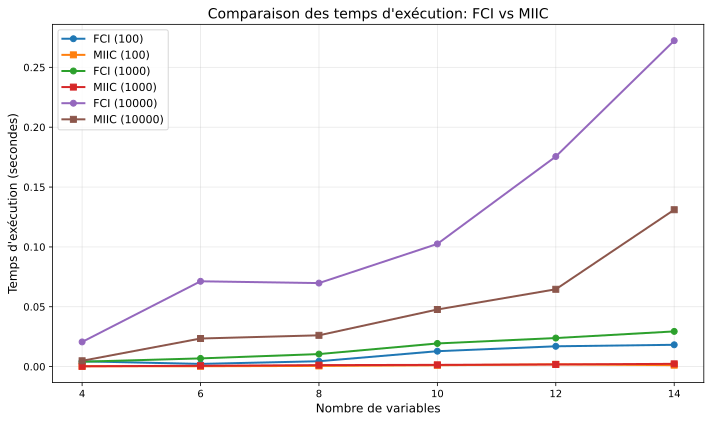


Résumé des temps d'exécution:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | FCI: 0.0044s | MIIC: 0.0003s | Ratio: 16.51x
n= 6 variables | FCI: 0.0023s | MIIC: 0.0003s | Ratio: 7.05x
n= 8 variables | FCI: 0.0045s | MIIC: 0.0006s | Ratio: 7.80x
n=10 variables | FCI: 0.0129s | MIIC: 0.0011s | Ratio: 11.32x
n=12 variables | FCI: 0.0170s | MIIC: 0.0019s | Ratio: 9.01x
n=14 variables | FCI: 0.0182s | MIIC: 0.0012s | Ratio: 14.96x

Taille de l'échantillo s = 1000
n= 4 variables | FCI: 0.0041s | MIIC: 0.0003s | Ratio: 14.21x
n= 6 variables | FCI: 0.0069s | MIIC: 0.0007s | Ratio: 9.72x
n= 8 variables | FCI: 0.0105s | MIIC: 0.0013s | Ratio: 8.33x
n=10 variables | FCI: 0.0194s | MIIC: 0.0015s | Ratio: 13.20x
n=12 variables | FCI: 0.0239s | MIIC: 0.0018s | Ratio: 13.08x
n=14 variables | FCI: 0.0294s | MIIC: 0.0023s | Ratio: 12.71x

Taille de l'échantillo s = 10000
n= 4 variables | FCI: 0.0206s | MIIC: 0.0049s | Ratio: 4.24x
n= 6 vari

In [19]:
# Comparaison des temps d'exécution
plt.figure(figsize=(10, 6))
for s in n_samples:
    plt.plot(n_vars_list, total_fci_times[s], marker='o', label=f'FCI ({s})', linewidth=2)
    plt.plot(n_vars_list, total_miic_times[s], marker='s', label=f'MIIC ({s})', linewidth=2)

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Temps d\'exécution (secondes)', fontsize=12)
plt.title('Comparaison des temps d\'exécution: FCI vs MIIC', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)

plt.tight_layout()
plt.savefig('graph/t_exec.svg')
plt.show()

# Affichage des statistiques
print("\nRésumé des temps d'exécution:")
print("-" * 60)

for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | FCI: {total_fci_times[s][i]:.4f}s | MIIC: {total_miic_times[s][i]:.4f}s | Ratio: {total_ratios[s][i]:.2f}x")

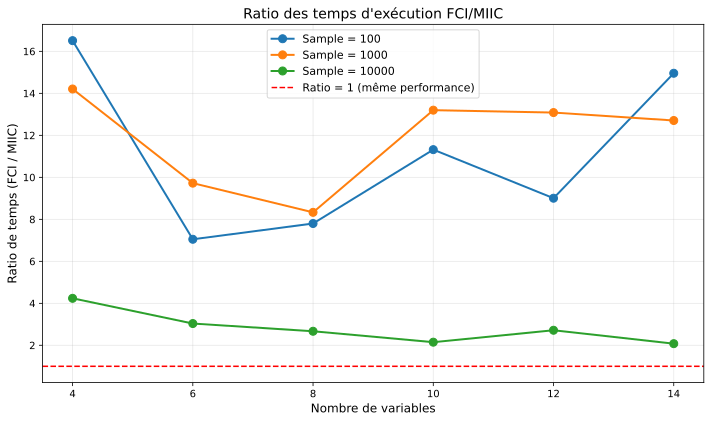


Résumé des ratios FCI/MIIC:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | Ratio:  16.51x
n= 6 variables | Ratio:   7.05x
n= 8 variables | Ratio:   7.80x
n=10 variables | Ratio:  11.32x
n=12 variables | Ratio:   9.01x
n=14 variables | Ratio:  14.96x

Taille de l'échantillo s = 1000
n= 4 variables | Ratio:  14.21x
n= 6 variables | Ratio:   9.72x
n= 8 variables | Ratio:   8.33x
n=10 variables | Ratio:  13.20x
n=12 variables | Ratio:  13.08x
n=14 variables | Ratio:  12.71x

Taille de l'échantillo s = 10000
n= 4 variables | Ratio:   4.24x
n= 6 variables | Ratio:   3.04x
n= 8 variables | Ratio:   2.67x
n=10 variables | Ratio:   2.15x
n=12 variables | Ratio:   2.72x
n=14 variables | Ratio:   2.08x


In [20]:
# Ratio FCI/MIIC
plt.figure(figsize=(10, 6))

for s in n_samples:
    plt.plot(n_vars_list, total_ratios[s], marker='o', linewidth=2, markersize=8, label=f'Sample = {s}')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Ratio = 1 (même performance)')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Ratio de temps (FCI / MIIC)', fontsize=12)
plt.title('Ratio des temps d\'exécution FCI/MIIC', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)

plt.tight_layout()
plt.savefig('graph/t_ratio.svg')
plt.show()

# Affichage des statistiques détaillées
print("\nRésumé des ratios FCI/MIIC:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | Ratio: {total_ratios[s][i]:6.2f}x")

### Analyse de structure

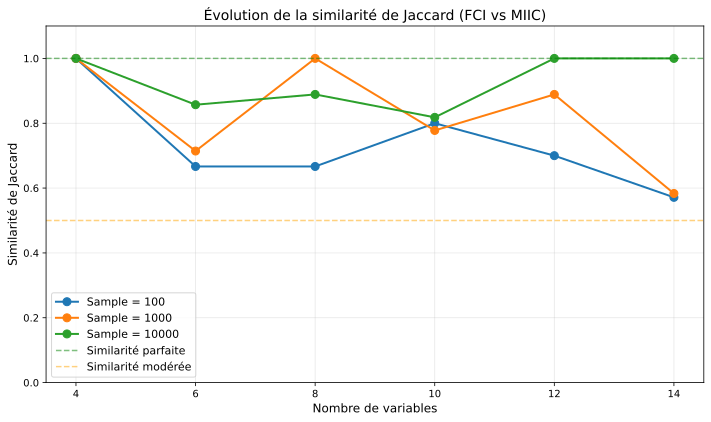


Résumé de la similarité de Jaccard:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | FCI:  4 arêtes | MIIC:  4 arêtes | Jaccard: 1.000
n= 6 variables | FCI:  2 arêtes | MIIC:  3 arêtes | Jaccard: 0.667
n= 8 variables | FCI:  4 arêtes | MIIC:  6 arêtes | Jaccard: 0.667
n=10 variables | FCI:  8 arêtes | MIIC: 10 arêtes | Jaccard: 0.800
n=12 variables | FCI:  7 arêtes | MIIC: 10 arêtes | Jaccard: 0.700
n=14 variables | FCI:  4 arêtes | MIIC:  7 arêtes | Jaccard: 0.571

Taille de l'échantillo s = 1000
n= 4 variables | FCI:  4 arêtes | MIIC:  4 arêtes | Jaccard: 1.000
n= 6 variables | FCI:  6 arêtes | MIIC:  6 arêtes | Jaccard: 0.714
n= 8 variables | FCI:  6 arêtes | MIIC:  6 arêtes | Jaccard: 1.000
n=10 variables | FCI:  7 arêtes | MIIC:  9 arêtes | Jaccard: 0.778
n=12 variables | FCI:  8 arêtes | MIIC:  9 arêtes | Jaccard: 0.889
n=14 variables | FCI:  7 arêtes | MIIC: 12 arêtes | Jaccard: 0.583

Taille de l'échantillo s = 10000

In [21]:
# Similarité de Jaccard 
plt.figure(figsize=(10, 6))

for s in n_samples:
    plt.plot(n_vars_list, total_jaccard_similarities[s], marker='o', linewidth=2, markersize=8, label=f'Sample = {s}')
plt.axhline(y=1, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Similarité parfaite')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Similarité modérée')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Similarité de Jaccard', fontsize=12)
plt.title('Évolution de la similarité de Jaccard (FCI vs MIIC)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.savefig('graph/jaccard.svg')
plt.show()

# Affichage des statistiques
print("\nRésumé de la similarité de Jaccard:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | FCI: {total_n_edges_fci[s][i]:2d} arêtes | MIIC: {total_n_edges_miic[s][i]:2d} arêtes | Jaccard: {total_jaccard_similarities[s][i]:.3f}")

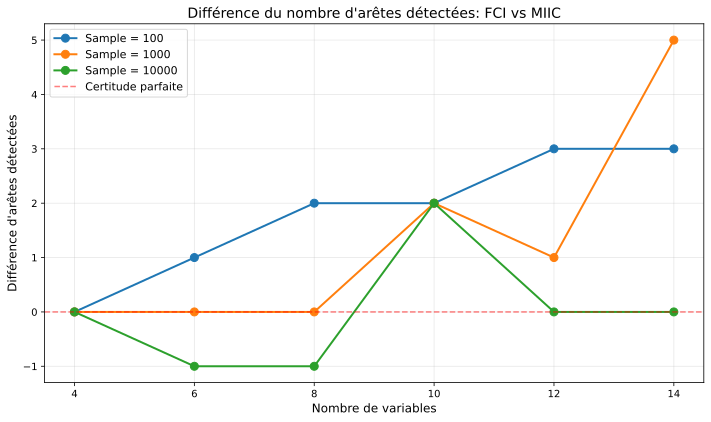


Résumé du nombre d'arêtes détectées:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | FCI:  4 arêtes | MIIC:  4 arêtes | Différence: +0
n= 6 variables | FCI:  2 arêtes | MIIC:  3 arêtes | Différence: +1
n= 8 variables | FCI:  4 arêtes | MIIC:  6 arêtes | Différence: +2
n=10 variables | FCI:  8 arêtes | MIIC: 10 arêtes | Différence: +2
n=12 variables | FCI:  7 arêtes | MIIC: 10 arêtes | Différence: +3
n=14 variables | FCI:  4 arêtes | MIIC:  7 arêtes | Différence: +3

Taille de l'échantillo s = 1000
n= 4 variables | FCI:  4 arêtes | MIIC:  4 arêtes | Différence: +0
n= 6 variables | FCI:  6 arêtes | MIIC:  6 arêtes | Différence: +0
n= 8 variables | FCI:  6 arêtes | MIIC:  6 arêtes | Différence: +0
n=10 variables | FCI:  7 arêtes | MIIC:  9 arêtes | Différence: +2
n=12 variables | FCI:  8 arêtes | MIIC:  9 arêtes | Différence: +1
n=14 variables | FCI:  7 arêtes | MIIC: 12 arêtes | Différence: +5

Taille de l'échantillo s = 1000

In [22]:
# Nombre d'arêtes trouvées par FCI vs MIIC
plt.figure(figsize=(10, 6))
for s in n_samples:
    diff = [(total_n_edges_miic[s][i] - total_n_edges_fci[s][i]) for i in range(len(n_vars_list))]
    plt.plot(n_vars_list, diff, marker='o', label=f'Sample = {s}', linewidth=2, markersize=8)
    # plt.plot(n_vars_list, total_n_edges_fci[s], marker='o', label=f'FCI ({s})', linewidth=2, markersize=8)
    # plt.plot(n_vars_list, n_edges_miic, marker='s', label=f'MIIC ({s})', linewidth=2, markersize=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Certitude parfaite')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Différence d\'arêtes détectées', fontsize=12)
plt.title('Différence du nombre d\'arêtes détectées: FCI vs MIIC', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)

plt.tight_layout()
plt.savefig('graph/edge_diff.svg')
plt.show()

# Affichage des statistiques détaillées
print("\nRésumé du nombre d'arêtes détectées:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        diff = total_n_edges_miic[s][i] - total_n_edges_fci[s][i]
        print(f"n={n:2d} variables | FCI: {total_n_edges_fci[s][i]:2d} arêtes | MIIC: {total_n_edges_miic[s][i]:2d} arêtes | Différence: {diff:+2d}")

### Taux de incertitude FCI

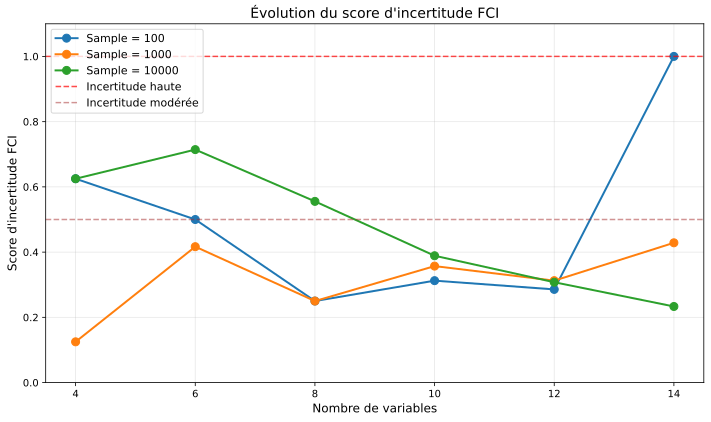


Résumé du score de certitude FCI:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | Score d'incertitude: 0.625
n= 6 variables | Score d'incertitude: 0.500
n= 8 variables | Score d'incertitude: 0.250
n=10 variables | Score d'incertitude: 0.312
n=12 variables | Score d'incertitude: 0.286
n=14 variables | Score d'incertitude: 1.000

Taille de l'échantillo s = 1000
n= 4 variables | Score d'incertitude: 0.125
n= 6 variables | Score d'incertitude: 0.417
n= 8 variables | Score d'incertitude: 0.250
n=10 variables | Score d'incertitude: 0.357
n=12 variables | Score d'incertitude: 0.312
n=14 variables | Score d'incertitude: 0.429

Taille de l'échantillo s = 10000
n= 4 variables | Score d'incertitude: 0.625
n= 6 variables | Score d'incertitude: 0.714
n= 8 variables | Score d'incertitude: 0.556
n=10 variables | Score d'incertitude: 0.389
n=12 variables | Score d'incertitude: 0.308
n=14 variables | Score d'incertitude: 0.233


In [23]:
# Taux de certitude FCI
plt.figure(figsize=(10, 6))

for s in n_samples:
    plt.plot(n_vars_list, total_uncertainty_score[s], marker='o', linewidth=2, markersize=8, label=f'Sample = {s}')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Incertitude haute')
plt.axhline(y=0.5, color='brown', linestyle='--', linewidth=1.5, alpha=0.5, label='Incertitude modérée')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Score d\'incertitude FCI', fontsize=12)
plt.title('Évolution du score d\'incertitude FCI', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.savefig('graph/uncertainty.svg')
plt.show()

# Affichage des statistiques
print("\nRésumé du score de certitude FCI:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | Score d'incertitude: {total_uncertainty_score[s][i]:.3f}")

In [26]:
# Test de sensibilité du paramètre alpha
print("Analyse de sensibilité du paramètre alpha")
print("-" * 60)

alpha_values = [0.001, 0.01, 0.05, 0.1, 0.2]
n_test = 10  # Nombre de variables pour le test


alpha_n_edges = []
alpha_uncertainty_scores = []
alpha_times = []

print(f"\nTest avec {n_test} variables et {n_samples[-1]} échantillons...")


bn_alpha_test = gum.randomBN(n=n_test, names=[f'X{i}' for i in range(n_test)])
bn_alpha_test.generateCPTs()


df_alpha_test, _ = utils.generate_test_data(bn_alpha_test, n_samples=n_samples[-1])

print(f"Données générées: {len(df_alpha_test)} échantillons\n")


for alpha in alpha_values:
    print(f"Test avec alpha = {alpha}...")
    
    
    fci_alpha, t_alpha = utils.measure_execution_time(run_FCI, df_alpha_test, alpha=alpha, useGum=True)
    fci_struct = utils.get_fci_structure(fci_alpha)

    n_edges = len(fci_struct['edges'])
    uncertainty = fci_struct['uncertainty_score']

    alpha_n_edges.append(n_edges)
    alpha_uncertainty_scores.append(uncertainty)
    alpha_times.append(t_alpha)
    
    print(f"  Arêtes détectées: {n_edges}, Score d'incertitude: {uncertainty:.3f}, Temps: {t_alpha:.4f}s")


Analyse de sensibilité du paramètre alpha
------------------------------------------------------------

Test avec 10 variables et 10000 échantillons...
Données générées: 10000 échantillons

Test avec alpha = 0.001...
  Arêtes détectées: 8, Score d'incertitude: 0.438, Temps: 0.1747s
Test avec alpha = 0.01...
  Arêtes détectées: 10, Score d'incertitude: 0.350, Temps: 0.3575s
Test avec alpha = 0.05...
  Arêtes détectées: 11, Score d'incertitude: 0.273, Temps: 0.2304s
Test avec alpha = 0.1...
  Arêtes détectées: 11, Score d'incertitude: 0.273, Temps: 0.2427s
Test avec alpha = 0.2...
  Arêtes détectées: 11, Score d'incertitude: 0.273, Temps: 0.1585s


### Impact du paramètre alpha

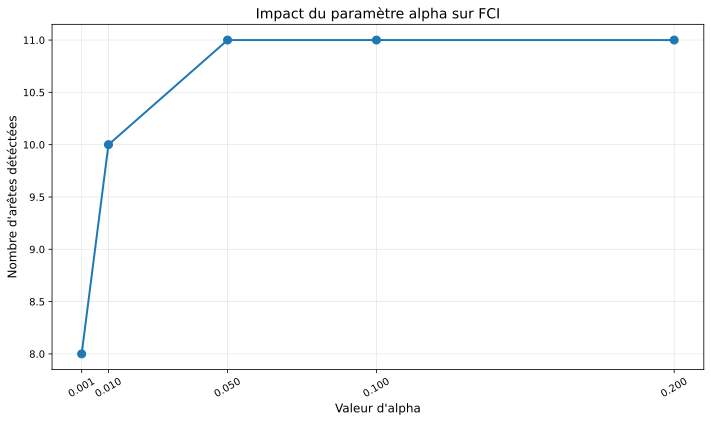

In [27]:
# alpha
plt.figure(figsize=(10, 6))

plt.plot(alpha_values, alpha_n_edges, marker='o', linewidth=2, markersize=8)

plt.xlabel('Valeur d\'alpha', fontsize=12)
plt.ylabel('Nombre d\'arêtes détéctées', fontsize=12)
plt.title('Impact du paramètre alpha sur FCI', fontsize=14)
# plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(alpha_values, rotation=30)


plt.tight_layout()
plt.savefig('graph/alpha.svg')
plt.show()